# Task 3: Exploratory Data Analysis (EDA)
**DecodeLabs Data Science Internship**

We explore the cleaned student dataset to discover patterns, trends, and outliers using statistics and visualizations.

## 1. Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
print("Libraries imported!")

Libraries imported!


## 2. Load Cleaned Dataset

In [13]:
df = pd.read_csv('/content/students.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (30, 10)


,StudentID,Name,Age,Gender,MathScore,ScienceScore,EnglishScore,Attendance,Grade,City
0,1,Ali Hassan,16,Male,85.0,78,90,95,A,Karachi
1,2,Sara Khan,17,Female,92.0,88,85,98,A,Lahore
2,3,Usman Ahmed,15,Male,60.0,55,70,80,C,Islamabad
3,4,Fatima Malik,16,Female,78.0,82,88,92,B,Karachi
4,5,Bilal Raza,17,Male,45.0,50,60,70,D,Peshawar


## 3. Basic Descriptive Statistics

In [14]:
print("=== Descriptive Statistics ===")
df['AvgScore'] = df[['MathScore', 'ScienceScore', 'EnglishScore']].mean(axis=1)
df[['MathScore','ScienceScore','EnglishScore','Attendance','AvgScore']].describe().round(2)

=== Descriptive Statistics ===


,MathScore,ScienceScore,EnglishScore,Attendance,AvgScore
count,28.00,30.00,30.00,30.00,30.00
mean,72.54,70.77,76.93,85.10,73.20
std,16.11,15.47,13.38,11.19,14.70
min,40.00,42.00,50.00,60.00,44.00
25%,61.50,58.50,68.50,78.50,61.92
50%,74.50,72.50,79.00,88.00,74.33
75%,86.50,84.25,87.75,93.75,84.83
max,95.00,92.00,98.00,99.00,95.00


## 4. Mean Scores by Gender

In [15]:
gender_stats = df.groupby('Gender')[['MathScore','ScienceScore','EnglishScore','AvgScore']].mean().round(2)
print("Average Scores by Gender:")
print(gender_stats)

Average Scores by Gender:
        MathScore  ScienceScore  EnglishScore  AvgScore
Gender                                                 
Female      79.73         80.87         85.27     81.96
Male        64.23         60.67         68.60     64.44


## 5. Grade Distribution

In [16]:
grade_counts = df['Grade'].value_counts().sort_index()
print("Grade Distribution:")
print(grade_counts)
print()
print(f"Most common grade: {grade_counts.idxmax()} ({grade_counts.max()} students)")

Grade Distribution:
Grade
A    10
B    10
C     5
D     4
F     1
Name: count, dtype: int64

Most common grade: A (10 students)


## 6. City-wise Student Count

In [17]:
city_counts = df['City'].value_counts()
print("Students per City:")
print(city_counts)

Students per City:
City
Karachi      8
Lahore       8
Islamabad    5
Peshawar     5
Quetta       4
Name: count, dtype: int64


## 7. Correlation Analysis

In [18]:
corr = df[['MathScore','ScienceScore','EnglishScore','Attendance','AvgScore']].corr().round(2)
print("Correlation Matrix:")
print(corr)

Correlation Matrix:
              MathScore  ScienceScore  EnglishScore  Attendance  AvgScore
MathScore          1.00          0.97          0.95        0.96      0.99
ScienceScore       0.97          1.00          0.97        0.98      0.99
EnglishScore       0.95          0.97          1.00        0.98      0.99
Attendance         0.96          0.98          0.98        1.00      0.98
AvgScore           0.99          0.99          0.99        0.98      1.00


## 8. Outlier Detection using IQR

In [19]:
score_cols = ['MathScore', 'ScienceScore', 'EnglishScore', 'Attendance']

print("Outlier Detection (IQR Method):")
for col in score_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: Q1={Q1}, Q3={Q3}, IQR={IQR:.1f}, Bounds=[{lower:.1f}, {upper:.1f}], Outliers={len(outliers)}")

Outlier Detection (IQR Method):
MathScore: Q1=61.5, Q3=86.5, IQR=25.0, Bounds=[24.0, 124.0], Outliers=0
ScienceScore: Q1=58.5, Q3=84.25, IQR=25.8, Bounds=[19.9, 122.9], Outliers=0
EnglishScore: Q1=68.5, Q3=87.75, IQR=19.2, Bounds=[39.6, 116.6], Outliers=0
Attendance: Q1=78.5, Q3=93.75, IQR=15.2, Bounds=[55.6, 116.6], Outliers=0


## 9. Attendance vs AvgScore — Trend Analysis

In [20]:
corr_val = df['Attendance'].corr(df['AvgScore'])
print(f"Correlation between Attendance and AvgScore: {corr_val:.3f}")
print()
# Bin attendance
bins = [0, 70, 80, 90, 100]
labels = ['<70%', '70-80%', '80-90%', '90-100%']
df['AttendanceBin'] = pd.cut(df['Attendance'], bins=bins, labels=labels)
print(df.groupby('AttendanceBin')['AvgScore'].mean().round(2))

Correlation between Attendance and AvgScore: 0.984

AttendanceBin
<70%       49.40
70-80%     60.71
80-90%     73.13
90-100%    87.33
Name: AvgScore, dtype: float64


/tmp/ipykernel_15449/1661415234.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('AttendanceBin')['AvgScore'].mean().round(2))


## 10. Visualizations
### 10.1 Score Distribution

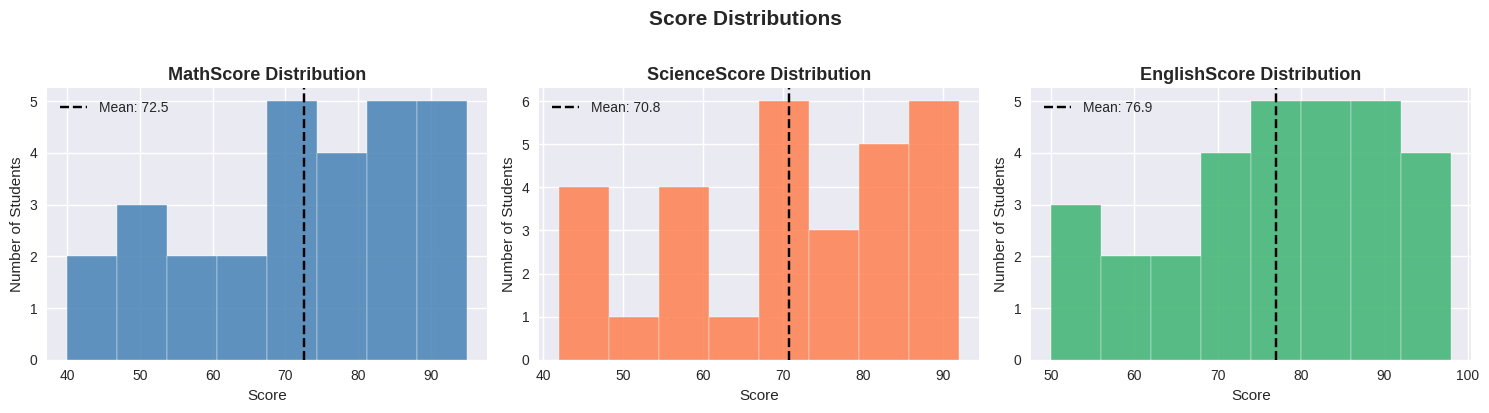

Chart saved!


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes, ['MathScore', 'ScienceScore', 'EnglishScore'], ['steelblue', 'coral', 'mediumseagreen']):
    ax.hist(df[col], bins=8, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Number of Students')
    ax.legend()

plt.suptitle('Score Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### 10.2 Grade Distribution Bar Chart

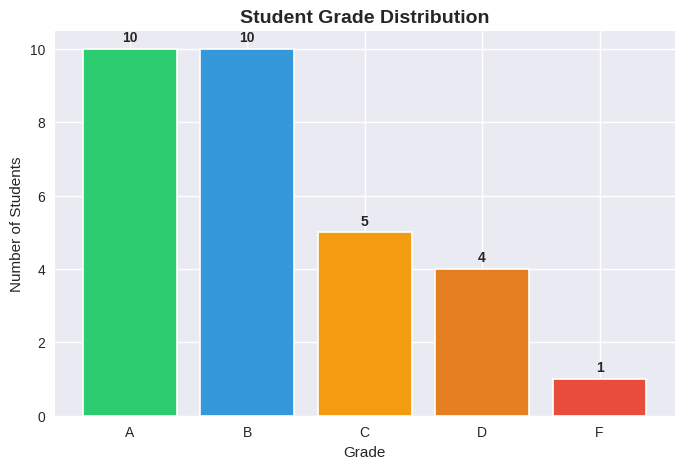

Chart saved!


In [22]:
grade_order = ['A', 'B', 'C', 'D', 'F']
grade_counts_ordered = df['Grade'].value_counts().reindex(grade_order, fill_value=0)
colors = ['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c']

plt.figure(figsize=(8, 5))
bars = plt.bar(grade_counts_ordered.index, grade_counts_ordered.values, color=colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, grade_counts_ordered.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, str(val), ha='center', fontweight='bold')

plt.title('Student Grade Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Grade')
plt.ylabel('Number of Students')
plt.savefig('grade_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### 10.3 Correlation Heatmap

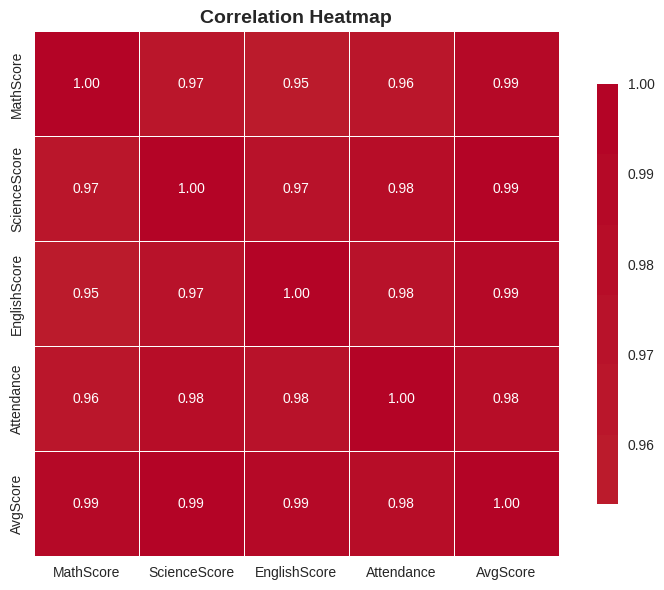

Chart saved!


In [23]:
corr_data = df[['MathScore','ScienceScore','EnglishScore','Attendance','AvgScore']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### 10.4 Attendance vs Avg Score Scatter Plot

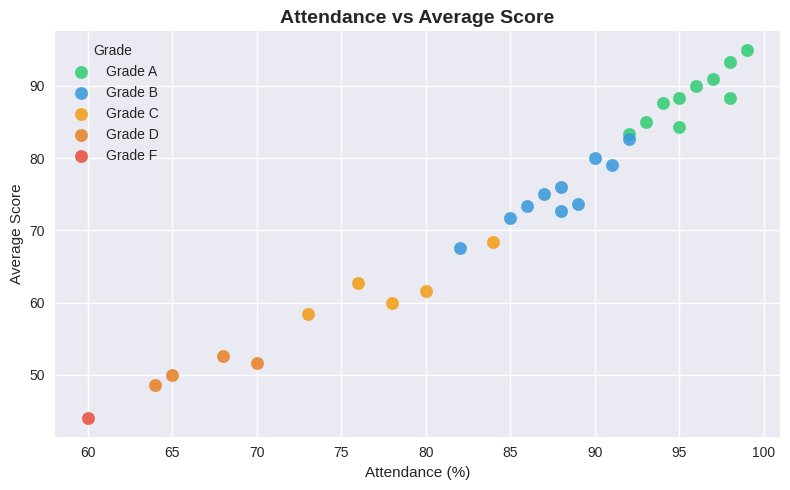

Chart saved!


In [24]:
plt.figure(figsize=(8, 5))
colors_map = {'A': '#2ecc71', 'B': '#3498db', 'C': '#f39c12', 'D': '#e67e22', 'F': '#e74c3c'}
for grade, group in df.groupby('Grade'):
    plt.scatter(group['Attendance'], group['AvgScore'],
                label=f'Grade {grade}', color=colors_map.get(grade, 'gray'), s=80, alpha=0.85)

plt.title('Attendance vs Average Score', fontsize=14, fontweight='bold')
plt.xlabel('Attendance (%)')
plt.ylabel('Average Score')
plt.legend(title='Grade')
plt.tight_layout()
plt.savefig('attendance_vs_score.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## 11. Key Findings Summary

In [25]:
print("=" * 50)
print("KEY FINDINGS FROM EDA")
print("=" * 50)
print(f"1. Total students analyzed   : {len(df)}")
print(f"2. Average Math Score        : {df['MathScore'].mean():.2f}")
print(f"3. Average Science Score     : {df['ScienceScore'].mean():.2f}")
print(f"4. Average English Score     : {df['EnglishScore'].mean():.2f}")
print(f"5. Average Attendance        : {df['Attendance'].mean():.2f}%")
print(f"6. Most common grade         : {df['Grade'].value_counts().idxmax()}")
print(f"7. Attendance-Score corr.    : {df['Attendance'].corr(df['AvgScore']):.3f} (positive!)")
print(f"8. Top performing city       : {df.groupby('City')['AvgScore'].mean().idxmax()}")
print(f"9. Gender with higher avg    : {df.groupby('Gender')['AvgScore'].mean().idxmax()}")
print("10. Higher attendance → Higher scores (clear trend observed)")

KEY FINDINGS FROM EDA
1. Total students analyzed   : 30
2. Average Math Score        : 72.54
3. Average Science Score     : 70.77
4. Average English Score     : 76.93
5. Average Attendance        : 85.10%
6. Most common grade         : A
7. Attendance-Score corr.    : 0.984 (positive!)
8. Top performing city       : Lahore
9. Gender with higher avg    : Female
10. Higher attendance → Higher scores (clear trend observed)


## ✅ Task 3 Complete!
We successfully:
- Computed descriptive statistics for all numeric columns
- Identified trends: attendance positively correlates with scores
- Detected potential outliers using IQR method
- Created 4 visualizations: histograms, bar chart, heatmap, scatter plot
- Summarized 10 key data insights